**MATRICE CORELATIE PHI**

Matricea a fost salvata cu succes la: /content/Images/Matrix.png


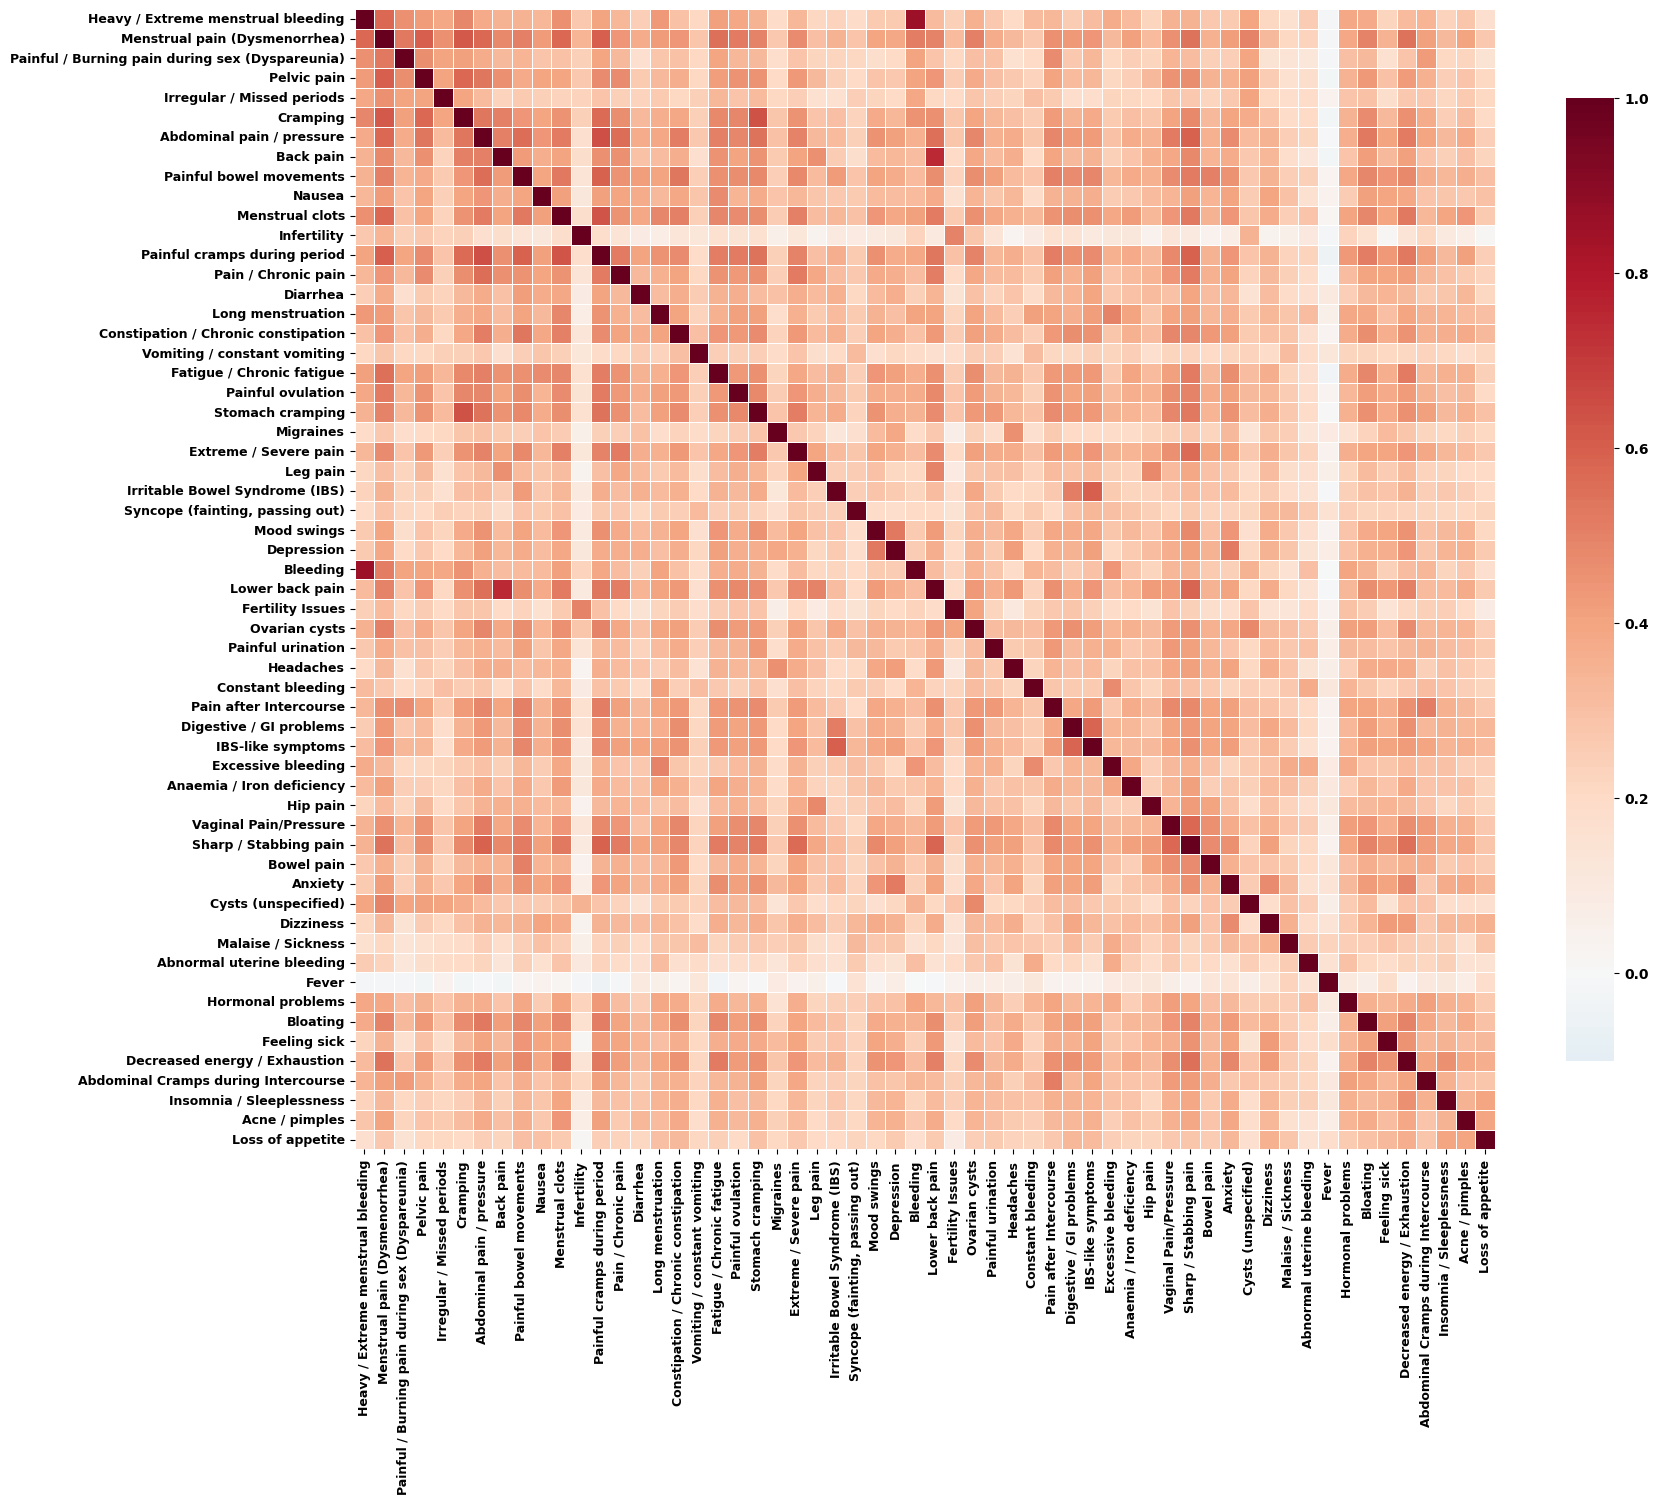

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

BASE_DIR = '/content'
IMAGES_DIR = os.path.join(BASE_DIR, 'Images')
os.makedirs(IMAGES_DIR, exist_ok=True)
dataset_path = "/content/dataset.xlsx"
df = pd.read_excel(dataset_path, engine="openpyxl")

X = df.drop(columns=["Unnamed: 0", "row", "label"], errors='ignore')

phi_matrix = X.corr(method='pearson')

plt.rcParams.update({'font.family': 'sans-serif', 'font.weight': 'bold'})

fig, ax = plt.subplots(figsize=(18, 16))

cmap = sns.color_palette("RdBu_r", as_cmap=True)

sns.heatmap(
    phi_matrix,
    cmap=cmap,
    vmin=-0.1, vmax=1.0,
    center=0,
    square=True,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={"shrink": .75},
    annot=False,
    ax=ax
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=9, fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()

salvare_path = os.path.join(IMAGES_DIR, 'Matrix.png')
plt.savefig(salvare_path, dpi=300, bbox_inches='tight', transparent=False, facecolor='white')

print(f"Matricea a fost salvata cu succes la: {salvare_path}")
plt.show()

CORELATIE SIMPTOM-DIAGNOSTIC

In [ ]:
import pandas as pd
import numpy as np
dataset_path = "/content/dataset.xlsx"
df = pd.read_excel(dataset_path, engine="openpyxl")

X = df.drop(columns=["Unnamed: 0", "row", "label"], errors='ignore')
y = df["label"].astype(int)

corr_with_label = X.corrwith(y, method='pearson').abs()

df_tab1 = corr_with_label[corr_with_label > 0.5].reset_index()
df_tab1.columns = ['Symptom', 'Phi Coefficient']
df_tab1 = df_tab1.sort_values('Phi Coefficient', ascending=False)

print(df_tab1.to_string(index=False))


                                        Symptom  Phi Coefficient
                  Menstrual pain (Dysmenorrhea)         0.713039
                   Painful cramps during period         0.611767
                                       Cramping         0.602516
                      Fatigue / Chronic fatigue         0.598330
             Heavy / Extreme menstrual bleeding         0.594275
                                       Bleeding         0.569073
                                    Pelvic pain         0.567080
                      Abdominal pain / pressure         0.563149
Painful / Burning pain during sex (Dyspareunia)         0.552379


CORELATIE PERECHI DE SIMPTOME

In [ ]:
import pandas as pd
import numpy as np

dataset_path = "/content/dataset.xlsx"
df = pd.read_excel(dataset_path, engine="openpyxl")

X = df.drop(columns=["Unnamed: 0", "row", "label"], errors='ignore')
y = df["label"].astype(int)

corr_matrix = X.corr(method='pearson').abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

pairs = []
for col in upper_tri.columns:
    for row in upper_tri.index:
        val = upper_tri.loc[row, col]
        if val > 0.5:
            pairs.append({'Symptom A': row, 'Symptom B': col, r'$\phi$': val})

df_tab2 = pd.DataFrame(pairs).sort_values(r'$\phi$', ascending=False)
print(df_tab2.to_string(index=False))

                         Symptom A                                       Symptom B   $\phi$
Heavy / Extreme menstrual bleeding                                        Bleeding 0.856982
                         Back pain                                 Lower back pain 0.748515
         Abdominal pain / pressure                    Painful cramps during period 0.643030
                          Cramping                                Stomach cramping 0.632649
                   Menstrual clots                    Painful cramps during period 0.626626
     Menstrual pain (Dysmenorrhea)                                        Cramping 0.614931
     Menstrual pain (Dysmenorrhea)                    Painful cramps during period 0.599771
    Irritable Bowel Syndrome (IBS)                               IBS-like symptoms 0.595615
     Menstrual pain (Dysmenorrhea)                                     Pelvic pain 0.592272
           Painful bowel movements                    Painful cramps during peri

**UMAP**

Calculăm UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


 UMAP calculat! Shape: (886, 2)


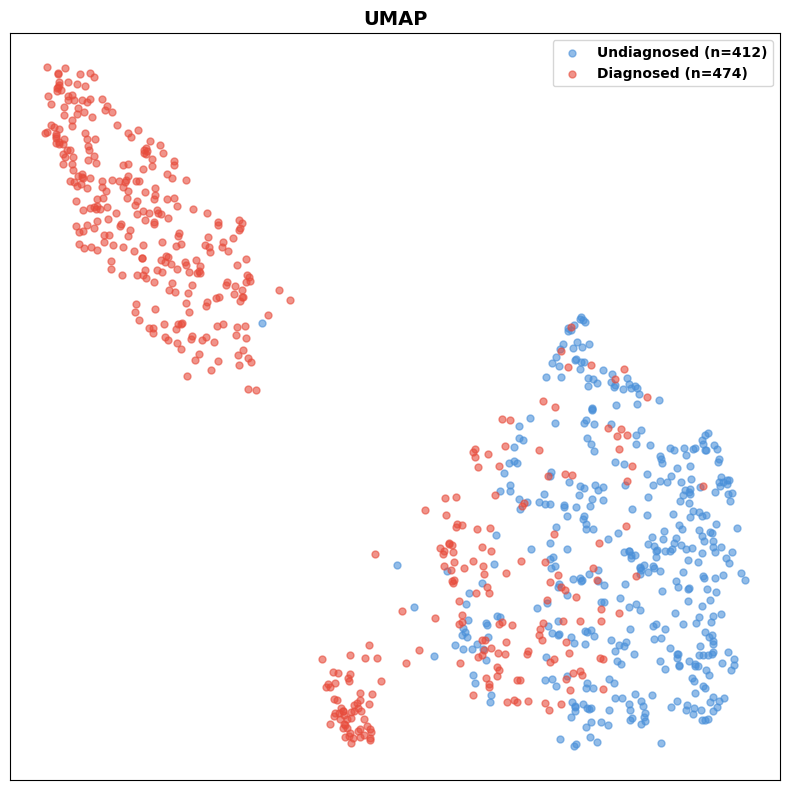

In [ ]:
!pip install umap-learn
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
BASE_DIR = '/content'
FIGURES_DIR = os.path.join(BASE_DIR, 'Figures')
os.makedirs(FIGURES_DIR, exist_ok=True)
dataset_path = os.path.join(BASE_DIR, 'dataset.xlsx')

if not os.path.exists(dataset_path):
    print(f"EROARE: Nu exista fisierul '{dataset_path}'")
else:
    df = pd.read_excel(dataset_path, engine="openpyxl")
    cols_to_drop = ["Unnamed: 0", "row", "label",]
    X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
    y = df["label"].astype(int)

    print("Calculăm UMAP...")
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        n_components=2,
        metric='hamming',
        random_state=42
    )

    embedding = reducer.fit_transform(X.astype(bool))
    print(f" UMAP calculat! Shape: {embedding.shape}")
    colors = {0: '#4A90D9', 1: '#E74C3C'}
    labels_map = {0: f'Undiagnosed (n={sum(y == 0)})',
                  1: f'Diagnosed (n={sum(y == 1)})'}
    plt.figure(figsize=(8, 8))
    for cls in [0, 1]:
        mask = y == cls
        plt.scatter(embedding[mask, 0], embedding[mask, 1],
                    c=colors[cls], label=labels_map[cls],
                    alpha=0.6, s=25)

    plt.title('UMAP', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.xticks([])
    plt.yticks([])
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    save_path = os.path.join(FIGURES_DIR, 'UMAP_binary_plot.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

**TSNE**

t-SNE calculat! Shape: (886, 2)
Figura salvata la: /content/Figures/tSNE_binary_plot.png


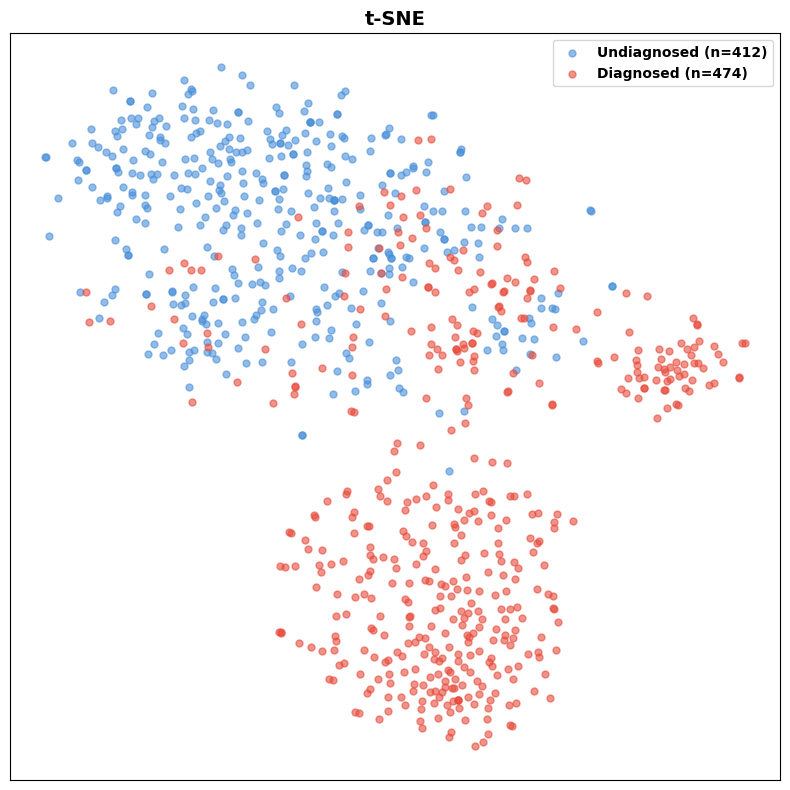

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
BASE_DIR = '/content'
FIGURES_DIR = os.path.join(BASE_DIR, 'Figures')
os.makedirs(FIGURES_DIR, exist_ok=True)
dataset_path = os.path.join(BASE_DIR, 'dataset.xlsx')

if not os.path.exists(dataset_path):
    print(f"EROARE: Nu exista fisierul '{dataset_path}'")
else:
    df = pd.read_excel(dataset_path, engine="openpyxl")
    cols_to_drop = ["Unnamed: 0", "row", "label"]
    X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
    y = df["label"].astype(int)
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate='auto',
        max_iter=1000,
        random_state=42,
        init='random',
        metric='hamming'
    )

    tsne_embedding = tsne.fit_transform(X.astype(bool))
    print(f"t-SNE calculat! Shape: {tsne_embedding.shape}")
    colors = {0: '#4A90D9', 1: '#E74C3C'}
    labels_map = {0: f'Undiagnosed (n={sum(y == 0)})',
                  1: f'Diagnosed (n={sum(y == 1)})'}
    plt.figure(figsize=(8, 8))
    for cls in [0, 1]:
        mask = y == cls
        plt.scatter(tsne_embedding[mask, 0], tsne_embedding[mask, 1],
                    c=colors[cls], label=labels_map[cls],
                    alpha=0.6, s=25)

    plt.title('t-SNE', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.xticks([])
    plt.yticks([])
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    save_path = os.path.join(FIGURES_DIR, 'tSNE_binary_plot.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Figura salvata la: {save_path}")
    plt.show()

**UMAP AND TSNE**

t-SNE calculat! Shape: (886, 2)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP calculat! Shape: (886, 2)


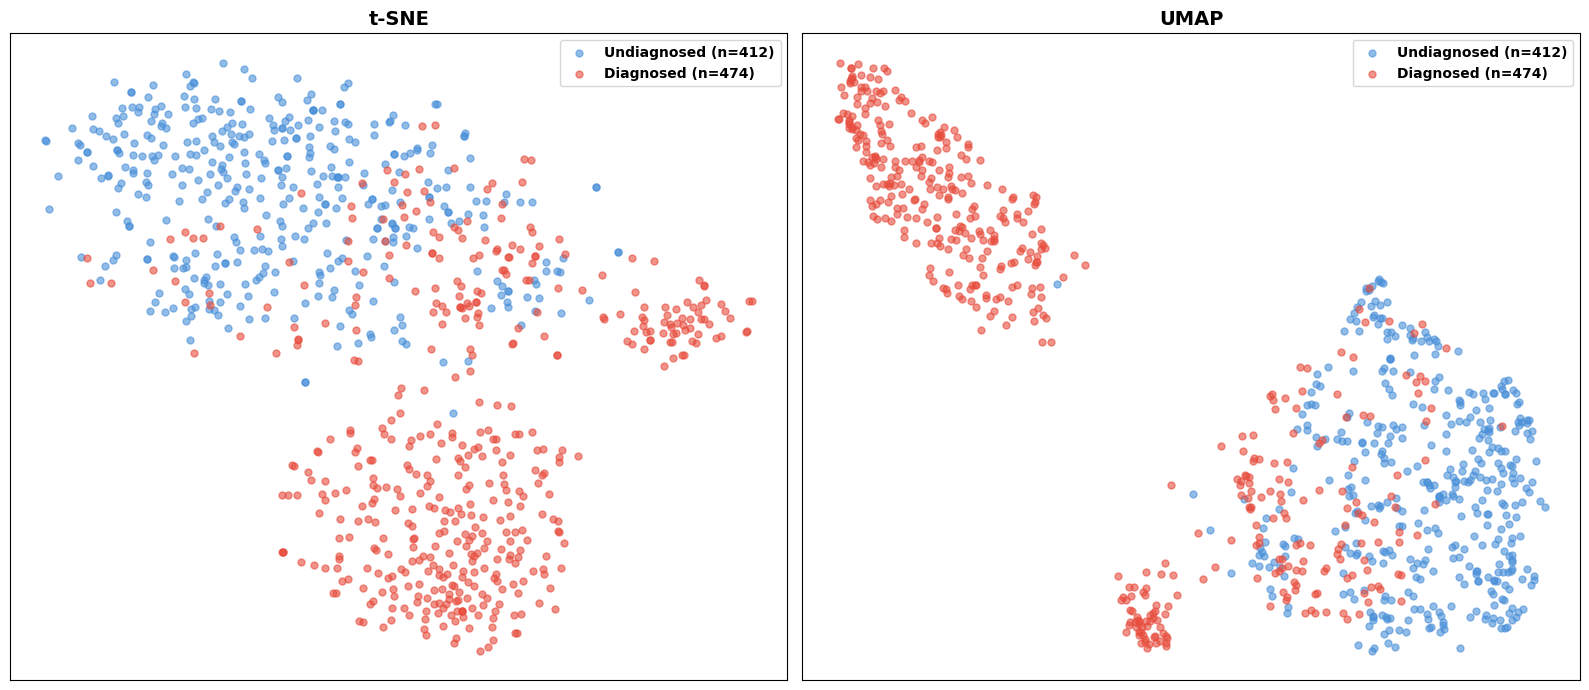

In [ ]:
!pip install umap-learn
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
from sklearn.manifold import TSNE
BASE_DIR = '/content'
FIGURES_DIR = os.path.join(BASE_DIR, 'Figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

dataset_path = os.path.join(BASE_DIR, 'dataset.xlsx')

if not os.path.exists(dataset_path):
    print(f"EROARE: Nu exista fisierul '{dataset_path}'")
else:
    df = pd.read_excel(dataset_path, engine="openpyxl")
    cols_to_drop = ["Unnamed: 0", "row", "label"]
    X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
    y = df["label"].astype(int)

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate='auto',
        max_iter=1000,
        random_state=42,
        init='random',
        metric='hamming'
    )
    tsne_embedding = tsne.fit_transform(X)
    print(f"t-SNE calculat! Shape: {tsne_embedding.shape}")
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        n_components=2,
        metric='hamming',
        random_state=42
    )
    umap_embedding = reducer.fit_transform(X)
    print(f"UMAP calculat! Shape: {umap_embedding.shape}")
    colors = {0: '#4A90D9', 1: '#E74C3C'}
    labels_map = {0: f'Undiagnosed (n={sum(y == 0)})',
                  1: f'Diagnosed (n={sum(y == 1)})'}

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    for cls in [0, 1]:
        mask = y == cls
        axes[0].scatter(tsne_embedding[mask, 0], tsne_embedding[mask, 1],
                        c=colors[cls], label=labels_map[cls], alpha=0.6, s=25)

    axes[0].set_title('t-SNE', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].set_xticks([])
    axes[0].set_yticks([])
    axes[0].grid(True, alpha=0.2)

    for cls in [0, 1]:
        mask = y == cls
        axes[1].scatter(umap_embedding[mask, 0], umap_embedding[mask, 1],
                        c=colors[cls], label=labels_map[cls], alpha=0.6, s=25)

    axes[1].set_title('UMAP', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].set_xticks([])
    axes[1].set_yticks([])
    axes[1].grid(True, alpha=0.2)

    plt.tight_layout()
    save_path = os.path.join(FIGURES_DIR, 'tSNE_UMAP_comparison.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()